# 2. Modelado y generación de insights

## 2.1. Introducción


Este notebook forma parte del proyecto **“Análisis Multimodal de Snacks Saludables”** y se centra en la **extracción de insights estratégicos y generación de informes ejecutivos** a partir de los datos preprocesados en el Notebook 1.  

Se emplean técnicas de **Inteligencia Artificial generativa (LLM, Gemini)** para analizar el contenido textual de artículos, blogs y transcripciones de podcasts sobre snacks saludables, con el objetivo de **transformar información bruta en insights estructurados y visualizaciones accionables**.  

El enfoque multimodal permite combinar distintas fuentes y tipos de contenido para identificar patrones de consumo, atributos valorados, percepciones de los consumidores y oportunidades de innovación.

**Objetivos del Notebook**

1. **Importar y validar el dataset preprocesado** generado en Notebook 1.  
2. **Extraer información estructurada** mediante LLM:
   - Productos mencionados
   - Atributos de interés (textura, sabor, ingredientes, presentación, precio, conveniencia)
   - Sentimiento de las menciones (positivo, neutro, negativo)  
3. **Clasificar productos en categorías estratégicas** para el análisis de mercado.  
4. **Generar un informe narrativo profundo** listo para presentación a la dirección de innovación, incluyendo tendencias, oportunidades y propuestas de nuevos productos.  
5. **Evaluar la originalidad del informe** comparándolo con benchmarks de mercado (20 resúmenes con enfoques variados).  
6. **Visualizar los resultados** mediante:
   - Mapas de calor de atributos vs categorías
   - Distribución de sentimientos ponderada por volumen

## 2.2. Importación de datos y librerías

Importamos las librerías y cargamos los datasets preprocesados en el anterior Notebook.

In [ ]:
# ==============================
# MANEJO DE DATOS Y CONFIGURACIÓN
# ==============================
import os                     # Manejo de rutas y sistema de archivos
from pathlib import Path       # Manejo de rutas de manera multiplataforma
import json                   # Leer y escribir datos en formato JSON
import pandas as pd           # Manejo de DataFrames y análisis de datos
import warnings               # Control de warnings en ejecución
from dotenv import load_dotenv # Cargar variables de entorno (API keys, etc.)

# ==============================
# MODELO LLM / API GENAI
# ==============================
import google.generativeai as genai  # Acceso a modelos generativos de Google

# ==============================
# VISUALIZACIÓN DE DATOS
# ==============================
import matplotlib.pyplot as plt   # Gráficos básicos (barras, líneas, etc.)
import seaborn as sns             # Visualizaciones estadísticas y mapas de calor
from IPython.display import display, Markdown  # Mostrar tablas y textos formateados en notebook

# ==============================
# ANÁLISIS DE TEXTO
# ==============================
from sklearn.feature_extraction.text import TfidfVectorizer  # Vectorización de texto
from sklearn.metrics.pairwise import cosine_similarity      # Medición de similitud entre textos

# ==============================
# UTILIDADES VARIAS
# ==============================
import time  # Medir tiempos de ejecución o pausas controladas
from collections import Counter  # Contar frecuencias de elementos en listas o iterables

C:\Users\Cristina\AppData\Local\Temp\ipykernel_2604\4107040737.py:8: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
# ==============================
# CARGAR DATASETS PREPROCESADOS
# ==============================

# Rutas a los datasets ya preparados
INPUT = r"H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\data\processed\02_dataset_preprocessed.csv"

# Cargar en dataframes
df = pd.read_csv(INPUT)

# Inspección rápida
print("Dataset global:")
print(df.head())
print(df.info())

Dataset global:
                                       content_clean            source type
0  titulo: recetas saludables contra el frío inve...  directoalpaladar  web
1  titulo: ejercicio físico en verano url: practi...              nutt  web
2  titulo: el agua en las comidas no engorda url:...              nutt  web
3  titulo: productos bio, veganos, sin gluten, si...        solnatural  web
4  titulo: calabacín rebozado y crujiente en frei...          vitonica  web
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   content_clean  17 non-null     object
 1   source         17 non-null     object
 2   type           17 non-null     object
dtypes: object(3)
memory usage: 540.0+ bytes
None


## 2.3. LLM

### 2.3.1. Generación de insights

En esta sección se utiliza el modelo Gemini para extraer información estructurada de los textos, transformando los contenidos en columnas que indiquen Productos, Atributos y Sentimiento. Se configura la clave de API y se inicializa el modelo (principal gemini-2.0-flash, con fallback a gemini-1.5-flash).

El prompt se diseña de manera que el modelo devuelva un JSON estrictamente estructurado, asegurando consistencia. La función procesar_rapido() recorre cada fila del dataframe, consulta al modelo y devuelve la información limpia y lista para análisis.

Al final de esta etapa se obtiene un dataset enriquecido que permite transformar texto libre en información accionable.

In [ ]:
# ==============================================================================
# 0. CONFIGURACIÓN ROBUSTA
# ==============================================================================
warnings.simplefilter(action='ignore', category=FutureWarning)
load_dotenv(override=True) 

raw_key = os.environ.get("GEMINI_API_KEY", "")
API_KEY = raw_key.strip().replace('"', '').replace("'", "")

if not API_KEY:
    raise ValueError("❌ No encuentro GEMINI_API_KEY en el archivo .env")

genai.configure(api_key=API_KEY)
print(f"✅ Clave configurada (Empieza por: {API_KEY[:5]}...)")

generation_config = {
    "temperature": 0.1,
    "response_mime_type": "application/json"
}

print("🧠 Iniciando modelo...")
try:
    model = genai.GenerativeModel("gemini-2.0-flash", generation_config=generation_config)
    print("🚀 Usando Gemini 2.0 Flash")
except:
    model = genai.GenerativeModel("gemini-1.5-flash", generation_config=generation_config)
    print("🚀 Usando Gemini 1.5 Flash")

# ==============================================================================
# 1. PROMPT
# ==============================================================================
PROMPT_NER = """
Extrae información semántica clave del siguiente texto sobre snacks saludables.
Devuelve EXCLUSIVAMENTE un JSON válido con esta estructura exacta:

{{
  "Productos": ["lista de strings"],
  "Atributos": ["lista de strings"],
  "Sentimiento": "positivo | neutro | negativo"
}}

Instrucciones:
- "Atributos": SOLO usa estos valores: ["textura", "sabor", "presentación", "precio", "ingredientes", "conveniencia"]
- Si no hay info, devuelve lista vacía [].

Texto:
\"\"\"{texto}\"\"\"
"""

# ==============================================================================
# 2. FUNCIÓN DE PROCESAMIENTO
# ==============================================================================
def procesar_rapido(prompt_tpl, texto_entrada):
    if not isinstance(texto_entrada, str) or len(texto_entrada) < 5: 
        return {}
    
    try:
        prompt_final = prompt_tpl.format(texto=texto_entrada[:15000])
        response = model.generate_content(prompt_final)
        
        # Limpieza de markdown
        texto_limpio = response.text.strip()
        if texto_limpio.startswith("```json"): texto_limpio = texto_limpio[7:]
        if texto_limpio.startswith("```"): texto_limpio = texto_limpio[3:]
        if texto_limpio.endswith("```"): texto_limpio = texto_limpio[:-3]
            
        return json.loads(texto_limpio)

    except Exception as e:
        print(f"⚠️ Fallo en fila: {e}")
        return {}

# ==============================================================================
# 3. EJECUCIÓN CON GUARDADO EN RUTA ESPECÍFICA
# ==============================================================================
if 'df' in locals() and not df.empty:
    print(f"\n⚡ Procesando {len(df)} filas...")
    
    col = "content_clean" 
    
    if col in df.columns:
        print("   -> Consultando a Gemini...")
        
        # 1. Obtenemos los resultados
        resultados_raw = df[col].apply(lambda x: procesar_rapido(PROMPT_NER, x)).tolist()
        
        # 2. Creamos DataFrame temporal
        df_nuevas_cols = pd.DataFrame(resultados_raw)
        
        # 3. LIMPIEZA
        print("   -> Formateando columnas...")
        for column in df_nuevas_cols.columns:
            df_nuevas_cols[column] = df_nuevas_cols[column].apply(
                lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
            )
            df_nuevas_cols[column] = df_nuevas_cols[column].fillna("")

        # 4. UNIÓN
        df = pd.concat([df.reset_index(drop=True), df_nuevas_cols], axis=1)
        
        print("\n✅ ¡TERMINADO!")
        print("📊 Nuevas columnas añadidas: ", list(df_nuevas_cols.columns))

        # ======================================================================
        # 5. GUARDADO DEL CSV (NUEVA SECCIÓN)
        # ======================================================================
        try:
            # Definimos la ruta exacta que pediste
            ruta_out = Path(r"H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\data\final\dataset_con_insights.csv")
            
            # Crea la carpeta 'final' si no existe (mkdir parents=True)
            ruta_out.parent.mkdir(parents=True, exist_ok=True)
            
            # Guardamos (utf-8-sig para que Excel lea bien los acentos)
            df.to_csv(ruta_out, index=False, encoding="utf-8-sig")
            
            print(f"\n💾 Archivo guardado correctamente en:\n   -> {ruta_out}")
            
        except Exception as e:
            print(f"\n❌ Error al guardar el CSV: {e}")

        # Muestra final
        try:
            cols_to_show = ["title"] + list(df_nuevas_cols.columns)
            display(df[cols_to_show].head(3))
        except:
            print(df.head(3))
            
    else:
        print(f"❌ Error: No encuentro la columna '{col}' en df.")
else:
    print("⚠️ Carga 'df' primero.")

✅ Clave configurada (Empieza por: AIzaS...)
🧠 Iniciando modelo...
🚀 Usando Gemini 2.0 Flash

⚡ Procesando 17 filas...
   -> Consultando a Gemini...
   -> Formateando columnas...

✅ ¡TERMINADO!
📊 Nuevas columnas añadidas:  ['Productos', 'Atributos', 'Sentimiento']

💾 Archivo guardado correctamente en:
   -> H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\data\final\dataset_con_insights.csv
                                       content_clean            source type  \
0  titulo: recetas saludables contra el frío inve...  directoalpaladar  web   
1  titulo: ejercicio físico en verano url: practi...              nutt  web   
2  titulo: el agua en las comidas no engorda url:...              nutt  web   

                                           Productos  \
0                                                      
1  agua, bebidas isotónicas, ropa ligera, ropa tr...   
2                                                      

                            Atributos Senti

#### A) Clasificación de productos por tipo de producto

Dada la heterogeneidad semántica de los productos mencionados en las fuentes, se empleó un modelo de lenguaje (Gemini) para agruparlos en tipos de prouctos: "Snack procesado saludable", "Snack reformulado", "Preparación casera", "Ingrediente base", "Ultraprocesado no saludable", "No relevante para snacks". Esta clasificación permite una interpretación contextual esencial para entender patrones de consumo y preparar visualizaciones relevantes.

In [ ]:
# ======================================
# 1. EXTRAER PRODUCTOS ÚNICOS
# ======================================
print("🔍 Extrayendo inventario único de productos...")

productos_brutos = []

if "Entidades" in df.columns:
    for item in df["Entidades"]:
        if isinstance(item, dict):
            productos_brutos.extend(item.get("Productos", []))
        elif isinstance(item, str):
            try:
                d = json.loads(item.replace("'", '"'))
                productos_brutos.extend(d.get("Productos", []))
            except: 
                continue
elif "Productos" in df.columns:
    for item in df["Productos"]:
        if isinstance(item, str) and item.strip():
            productos_brutos.extend([p.strip() for p in item.split(",")])

# Limpieza y deduplicación
productos_unicos = sorted({p.lower().strip() for p in productos_brutos if p and len(p) > 2})

if not productos_unicos:
    raise ValueError("❌ No se encontraron productos en el DataFrame.")

print(f"📦 Total productos encontrados: {len(productos_brutos)}")
print(f"✨ Productos únicos a clasificar: {len(productos_unicos)}")

# ======================================
# 2. CREAR PROMPT PARA GEMINI
# ======================================
CATEGORIAS = [
    "Snack procesado saludable",
    "Snack reformulado",
    "Preparación casera",
    "Ingrediente base",
    "Ultraprocesado no saludable",
    "No relevante para snacks"
]

lista_txt = "\n".join(f"- {p}" for p in productos_unicos)

prompt_clasificacion = f"""
Eres un experto en I+D alimentario. Clasifica cada término de la lista en UNA de estas categorías:
{', '.join(CATEGORIAS)}.
Devuelve un JSON válido con producto: categoría.

LISTA A CLASIFICAR:
{lista_txt}
"""

# ======================================
# 3. LLAMADA A GEMINI
# ======================================
print("🤖 Consultando a Gemini...")

try:
    response = model.generate_content(prompt_clasificacion)
    texto_limpio = response.text.strip().replace("```json", "").replace("```", "")
    datos_crudos = json.loads(texto_limpio)

    # Normalizamos salida a diccionario
    if isinstance(datos_crudos, list):
        diccionario_final = {}
        for item in datos_crudos:
            if isinstance(item, dict):
                diccionario_final.update(item)
    elif isinstance(datos_crudos, dict):
        diccionario_final = datos_crudos
    else:
        diccionario_final = {}

    print(f"✅ Clasificación completada: {len(diccionario_final)} productos.")

except Exception as e:
    print(f"❌ Error procesando el JSON: {e}")
    diccionario_final = {}

# ======================================
# 4. CREAR DATAFRAME Y GUARDAR
# ======================================
if diccionario_final:
    df_tipos_productos = pd.DataFrame(list(diccionario_final.items()), columns=["Producto", "Categoria"])

    ruta_base = Path(r"H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\data\final")
    ruta_base.mkdir(parents=True, exist_ok=True)
    ruta_final = ruta_base / "clasificacion_productos_gemini.csv"

    df_tipos_productos.to_csv(ruta_final, index=False, encoding="utf-8")
    print(f"💾 Maestro guardado en: {ruta_final}")

    display(df_tipos_productos.head())
else:
    print("⚠️ No se generó diccionario final.")

# ======================================
# 5. INTEGRAR CATEGORÍAS EN EL DF ORIGINAL
# ======================================
if diccionario_final and "Entidades" in df.columns:
    print("🔄 Enriqueciendo datos...")

    mapa_rapido = {k.lower(): v for k, v in diccionario_final.items()}

    def asignar_categorias(entidad_json):
        if not isinstance(entidad_json, dict):
            return entidad_json
        prods = entidad_json.get("Productos", [])
        if isinstance(prods, str): prods = [prods]
        entidad_json["Categoria_producto"] = [mapa_rapido.get(p.lower(), "Desconocido") for p in prods if isinstance(p, str)]
        return entidad_json

    df["Entidades"] = df["Entidades"].apply(asignar_categorias)
    print("✅ Columna 'Entidades' actualizada con categorías.")

🔍 Extrayendo inventario único de productos...
📦 Total productos encontrados: 168
✨ Productos únicos a clasificar: 140
🤖 Consultando a Gemini...
✅ Clasificación completada: 140 productos.
💾 Maestro guardado en: H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\data\final\clasificacion_productos_gemini.csv


,Producto,Categoria
0,aceite de coco,Ingrediente base
1,aceite de oliva virgen extra,Ingrediente base
2,agua,Ingrediente base
3,alimentos ultraprocesados,Ultraprocesado no saludable
4,almendras,Ingrediente base


### 2.3.2. Generación del Resumen

Se crea un informe narrativo para la dirección de innovación mediante un prompt avanzado, el modelo redacta un texto completo que resume tendencias, ingredientes, oportunidades y conceptos de producto.

Este informe combina todos los textos content_clean en un solo documento, priorizando insights diferenciadores y conectando ideas de manera coherente. El resultado se guarda en un archivo .txt y permite a la empresa interpretar patrones de mercado sin necesidad de procesar los datos brutos.

In [ ]:
# ============================================================================== 
# 0. PROMPT PARA INFORME PROFUNDO
# ==============================================================================
PROMPT_INFORME_PROFUNDO = """
Eres un Consultor Senior de Estrategia de Mercado y de Innovación en Alimentación.
Trabajas en una empresa de alimentación que quiere lanzar nuevos snacks saludables.

Tienes acceso al siguiente contenido de múltiples artículos y fuentes sobre el mercado de snacks saludables (content_clean):
{contenido}

INSTRUCCIONES:

- Redacta un **informe narrativo completo**, listo para leer en un comité de innovación.
- Usa **párrafos fluidos separados por doble salto de línea (\n\n)**.
- Incluye **títulos de sección** claros, cortos y profesionales (por ejemplo: "Tendencias de Consumo", "Ingredientes y Productos Clave", "Oportunidades de Innovación"), pero **no listas, etiquetas ni JSON**.
- Prioriza los **insights más relevantes y diferenciadores**, incluyendo patrones recurrentes y oportunidades.
- Conecta ideas de forma fluida y profesional, evitando frases superficiales o genéricas.
- Describe **tendencias de mercado, hábitos de consumo, segmentos de consumidores, productos y combinaciones de ingredientes de interés**, y oportunidades de innovación.
- Señala **oportunidades de innovación y negocio**, incluyendo nichos de mercado y gaps que la empresa podría aprovechar.
- Genera **ideas concretas de nuevos snacks** o reformulaciones basadas en los insights extraídos.Incluye **ideas concretas de nuevos snacks o reformulaciones**, basadas en los insights del contenido.

Redacta el texto como si fuera a ser presentado directamente a la dirección de innovación de la empresa. Los títulos deben **introducir la sección**, seguidos de párrafos narrativos fluidos. No uses ningún tipo de estructura esquemática ni JSON, solo texto profundo y bien redactado.
"""

# ============================================================================== 
# 1. FUNCION PARA GENERAR INFORME GLOBAL PROFUNDO
# ==============================================================================
def generar_informe_global_profundo(df, max_chars=15000):
    """
    Genera un informe ejecutivo profundo a partir de content_clean.
    
    Args:
        df (pd.DataFrame): DataFrame con columna 'content_clean'
        max_chars (int): Máximo de caracteres a pasar al modelo (evita límites de tokens)
    
    Returns:
        str: Informe narrativo profundo
    """
    if df.empty or "content_clean" not in df.columns:
        print("⚠️ DataFrame vacío o no contiene 'content_clean'.")
        return ""
    
    # Combinar todo content_clean en un solo texto
    textos = df["content_clean"].dropna().astype(str).tolist()
    contenido_combinado = " ".join(textos)[:max_chars]  # truncar para evitar límite de tokens
    
    # Preparar prompt
    prompt = PROMPT_INFORME_PROFUNDO.format(contenido=contenido_combinado)
    
    # Generar informe
    try:
        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        print("❌ Error generando informe profundo:", e)
        return ""

# ============================================================================== 
# 2. EJECUCIÓN 
# ==============================================================================
if 'df' in locals() and not df.empty:
    print("⚡ Generando INFORME EJECUTIVO global profundo...")
    
    # Generar informe profundo
    informe_global = generar_informe_global_profundo(df)
    
    print(informe_global[:1500], "...")  # Muestra primeros 1500 caracteres
else:
    print("⚠️ Carga 'df' primero.")

⚡ Generando INFORME EJECUTIVO global profundo...
{
  "informe": {
    "titulo": "Informe de Estrategia de Mercado e Innovación en Snacks Saludables",
    "contenido": "A continuación, se presenta un informe narrativo sobre el mercado de snacks saludables, basado en el análisis de diversas fuentes y artículos. El objetivo es identificar tendencias clave, oportunidades de innovación y posibles nuevos productos para nuestra empresa.\n\n### Tendencias de Consumo y Salud\n\nEl consumidor actual busca cada vez más opciones de snacks que no solo sean convenientes y sabrosos, sino también saludables y nutritivos. Existe una creciente preocupación por el bienestar, lo que impulsa la demanda de productos con ingredientes naturales, bajos en azúcares, sin gluten, veganos y ecológicos. La hidratación también juega un papel crucial, especialmente durante los meses de verano, lo que abre la puerta a snacks que contribuyan a mantener los niveles adecuados de líquidos y electrolitos.\n\nLa alimentació

In [38]:
# Convertir string JSON a diccionario Python
informe_dict = json.loads(informe_global)

# Extraer título y contenido
titulo = informe_dict["informe"]["titulo"]
contenido = informe_dict["informe"]["contenido"]

# Crear string limpio para mostrar
texto_limpio = f"# {titulo}\n\n{contenido}"

# Mostrar en Jupyter como Markdown
display(Markdown(texto_limpio))

# Guardar en tu carpeta outputs
ruta_salida = r"H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\outputs\resumen_mercado_snacks_saludables.txt"
with open(ruta_salida, "w", encoding="utf-8") as f:
    f.write(f"{titulo}\n\n{contenido}")

print(f"💾 Informe guardado en: {ruta_salida}")


# Informe de Estrategia de Mercado e Innovación en Snacks Saludables

A continuación, se presenta un informe narrativo sobre el mercado de snacks saludables, basado en el análisis de diversas fuentes y artículos. El objetivo es identificar tendencias clave, oportunidades de innovación y posibles nuevos productos para nuestra empresa.

### Tendencias de Consumo y Salud

El consumidor actual busca cada vez más opciones de snacks que no solo sean convenientes y sabrosos, sino también saludables y nutritivos. Existe una creciente preocupación por el bienestar, lo que impulsa la demanda de productos con ingredientes naturales, bajos en azúcares, sin gluten, veganos y ecológicos. La hidratación también juega un papel crucial, especialmente durante los meses de verano, lo que abre la puerta a snacks que contribuyan a mantener los niveles adecuados de líquidos y electrolitos.

La alimentación ya no se ve solo como una necesidad, sino como una herramienta para mejorar la salud y el rendimiento físico. Esto se refleja en la búsqueda de alimentos que ayuden a controlar el peso, mejorar la digestión y aumentar la energía. Además, hay una mayor conciencia sobre la importancia de evitar alimentos ultraprocesados y optar por alternativas caseras o mínimamente procesadas.

### Ingredientes y Productos Clave

Las legumbres, las verduras de temporada y las frutas frescas son ingredientes estrella en la búsqueda de snacks saludables. El calabacín, por ejemplo, puede transformarse en un aperitivo crujiente y nutritivo utilizando la freidora de aire, evitando así las grasas y calorías de las frituras tradicionales. Los frutos secos, las semillas y los cereales integrales también son opciones populares para añadir fibra, proteínas y grasas saludables a los snacks.

En cuanto a los productos, se observa una tendencia hacia alternativas a los snacks convencionales, como patatas fritas y dulces. Los consumidores buscan opciones más nutritivas y menos adictivas, como verduras rebozadas, frutas deshidratadas, barritas energéticas caseras y mezclas de frutos secos y semillas. Los productos bio, veganos, sin gluten y sin azúcar añadido también están ganando terreno en el mercado.

### Oportunidades de Innovación y Negocio

Existe una clara oportunidad para desarrollar snacks que combinen sabor, salud y conveniencia. Se pueden explorar nuevas formulaciones con ingredientes naturales y nutritivos, como legumbres, verduras, frutas, frutos secos y semillas. La freidora de aire ofrece una alternativa saludable para elaborar snacks crujientes y sabrosos, sin necesidad de utilizar grandes cantidades de aceite.

Un nicho de mercado interesante son los snacks diseñados para deportistas y personas activas. Estos productos deben proporcionar energía sostenida, hidratación y nutrientes esenciales para el rendimiento y la recuperación. Se pueden desarrollar barritas energéticas, batidos de frutas y verduras, y mezclas de frutos secos y semillas con ingredientes específicos para deportistas.

Otra oportunidad es crear snacks que ayuden a controlar el peso y mejorar la digestión. Estos productos deben ser ricos en fibra, bajos en calorías y azúcares, y contener ingredientes que favorezcan la saciedad y el tránsito intestinal. Se pueden explorar opciones como galletas integrales con semillas, crackers de verduras y frutas deshidratadas.

### Ideas Concretas de Nuevos Snacks

1.  **Calabacín Crujiente con Especias:** Rodajas de calabacín rebozadas en pan rallado integral y especias naturales, cocinadas en freidora de aire. Se pueden ofrecer diferentes sabores, como pimentón, curry o hierbas provenzales.

2.  **Barritas Energéticas de Legumbres y Frutos Secos:** Barritas elaboradas con una base de legumbres (como garbanzos o lentejas) y frutos secos, endulzadas con dátiles o miel. Se pueden añadir ingredientes como semillas de chía, bayas de goji o cacao puro.

3.  **Snack de Zanahoria y Remolacha Deshidratada:** Chips de zanahoria y remolacha deshidratada con un toque de sal marina y especias. Una alternativa saludable y crujiente a las patatas fritas.

4.  **Mezcla de Frutos Secos y Semillas con Algas:** Combinación de frutos secos, semillas y algas marinas, rica en minerales y antioxidantes. Ideal para deportistas y personas que buscan un snack nutritivo y energético.

5.  **Galletas Integrales de Avena y Manzana:** Galletas elaboradas con harina integral de avena, manzana rallada y especias. Una opción saludable y deliciosa para el desayuno o la merienda.

Estas son solo algunas ideas iniciales. Se recomienda realizar estudios de mercado y pruebas de concepto para validar el potencial de cada producto y adaptarlo a las necesidades y preferencias de los consumidores.

💾 Informe guardado en: H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\outputs\resumen_mercado_snacks_saludables.txt


## 2.4. Evaluación del modelo LLM

Para evaluar la originalidad y cobertura del informe, se generan 20 resúmenes adicionales con distintos focos estratégicos (proteína vegetal, snacks para niños, sostenibilidad, texturas innovadoras, etc.).

Estos benchmarks se generan directamente en Gemini y no utilizan los datos recopilados ni procesados en el proyecto. Se basan únicamente en el conocimiento general del modelo sobre el mercado de snacks saludables.

Cada resumen se segmenta en las mismas secciones que el informe principal: tendencias, ingredientes, oportunidades e ideas. Esta etapa permite comparar el informe global con referencias de mercado externas, identificando qué partes del análisis aportan valor diferencial y originalidad frente al conocimiento general disponible.

### 2.4.1. Generación benchmark

In [ ]:
# Lista de enfoques para asegurar que los 20 resúmenes sean variados y cubran todo el espectro
enfoques = [
    "Salud Digestiva y Probióticos", "Proteína Vegetal y Plant-Based", "Snacking para Niños (Kids)",
    "Salud Mental y Mood Food (Adaptógenos)", "Sostenibilidad y Upcycling", "Sabores Étnicos y Picantes",
    "Snacks Bajos en Azúcar y Keto", "Texturas Innovadoras y Experiencias Sensoriales", "Snacks para Deportistas y Rendimiento",
    "Ingredientes Ancestrales y Superfoods", "Convenience y Formatos On-the-Go", "Etiquetado Limpio y Transparencia",
    "Snacks Nocturnos y Relajación", "Bebidas Funcionales como Snack", "Alternativas a la Carne (Jerky vegano)",
    "Frutas y Verduras Deshidratadas", "Salud Inmunológica", "Personalización y Tech-Food",
    "Nostalgia y Sabores Retro Renovados", "Precios Asequibles y Valor Percibido"
]

lista_resumenes_benchmark = []

print("🚀 Iniciando generación de Benchmark (Conocimiento General)...")

for i, enfoque in enumerate(enfoques):
    print(f"  -> Generando informe {i+1}/20: Foco en {enfoque}...")
    
    # Inyectamos el enfoque en el prompt para variar la salida
    PROMPT_BENCHMARK = f"""
    Eres un Consultor Senior de Estrategia de Mercado y de Innovación en Alimentación.
    
    TAREA:
    Genera un informe estratégico de mercado basado en tu CONOCIMIENTO GENERAL sobre tendencias globales de snacks saludables.
    
    FOCO ESPECÍFICO DEL INFORME:
    Aunque debes cubrir el mercado general, pon especial énfasis en analizar la tendencia de: **{enfoque}**.
    
    INSTRUCCIONES:
    - Redacta un **informe narrativo completo**, listo para leer en un comité de innovación.
    - Usa **párrafos fluidos separados por doble salto de línea**.
    - Incluye **títulos de sección** claros y profesionales.
    - **NO uses listas, bullets ni JSON**. Solo prosa.
    - Describe tendencias, hábitos, ingredientes y oportunidades.
    - Propone ideas concretas de nuevos snacks relacionadas con {enfoque}.
    
    Redacta el texto con profundidad y estilo directivo.
    """
    
    try:
        # Usamos una temperatura un poco más alta (0.7) para fomentar creatividad
        response = model.generate_content(
            PROMPT_BENCHMARK,
            generation_config={"temperature": 0.7}
        )
        lista_resumenes_benchmark.append({
            "id": i,
            "enfoque": enfoque,
            "resumen_texto": response.text.strip()
        })
        time.sleep(1) # Pequeña pausa para no saturar la API
    except Exception as e:
        print(f"⚠️ Error en iteración {i}: {e}")

# Guardamos los resultados
# 1. Definimos la ruta exacta donde quieres guardar
ruta_carpeta = Path(r"H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\data\final")

# 2. Creamos la carpeta si no existe (medida de seguridad)
ruta_carpeta.mkdir(parents=True, exist_ok=True)

# 3. Definimos el nombre completo del archivo
ruta_archivo = ruta_carpeta / "benchmark_20_resumenes.csv"

# 4. Creamos el DataFrame y guardamos
df_benchmark = pd.DataFrame(lista_resumenes_benchmark)
df_benchmark.to_csv(ruta_archivo, index=False)

print(f"✅ ¡Benchmark completado! Guardado en:\n{ruta_archivo}")

🚀 Iniciando generación de Benchmark (Conocimiento General)...
  -> Generando informe 1/20: Foco en Salud Digestiva y Probióticos...
  -> Generando informe 2/20: Foco en Proteína Vegetal y Plant-Based...
  -> Generando informe 3/20: Foco en Snacking para Niños (Kids)...
  -> Generando informe 4/20: Foco en Salud Mental y Mood Food (Adaptógenos)...
  -> Generando informe 5/20: Foco en Sostenibilidad y Upcycling...
  -> Generando informe 6/20: Foco en Sabores Étnicos y Picantes...
  -> Generando informe 7/20: Foco en Snacks Bajos en Azúcar y Keto...
  -> Generando informe 8/20: Foco en Texturas Innovadoras y Experiencias Sensoriales...
  -> Generando informe 9/20: Foco en Snacks para Deportistas y Rendimiento...
  -> Generando informe 10/20: Foco en Ingredientes Ancestrales y Superfoods...
  -> Generando informe 11/20: Foco en Convenience y Formatos On-the-Go...
  -> Generando informe 12/20: Foco en Etiquetado Limpio y Transparencia...
  -> Generando informe 13/20: Foco en Snacks Nocturno

### 2.4.2. Agrupación por secciones

Todos los informes, tanto el global como los 20 benchmarks generados en Gemini, se dividen en cuatro secciones clave: tendencias, ingredientes, oportunidades e ideas. Esto permite analizar cada aspecto de manera estructurada y comparar directamente los insights entre el informe principal y los benchmarks de referencia.

In [ ]:
#Dividir en secciones los resumenes
print("🔪 Iniciando segmentación semántica de informes...")

# Función auxiliar para limpiar el JSON
def limpiar_json(texto_respuesta):
    return texto_respuesta.replace("```json", "").replace("```", "").strip()

def extraer_secciones(texto_informe):
    """
    Usa Gemini para dividir el informe en 4 bloques JSON estándar.
    """
    PROMPT_PARSER = """
    Analiza el siguiente texto y extrae su contenido dividiéndolo en estas 4 claves JSON exactas.
    Si no encuentras una sección exacta, pon el contenido más relacionado.
    
    1. "tendencias": Todo lo relacionado con consumidor, salud y mercado.
    2. "ingredientes": Todo lo relacionado con materias primas, superalimentos y productos clave.
    3. "oportunidades": Nichos de mercado, gaps y ocasiones de consumo.
    4. "ideas": Conceptos concretos de snacks, recetas o ejemplos de producto.

    Devuelve SOLO el JSON válido.
    
    TEXTO:
    {texto}
    """
    try:
        res = model.generate_content(PROMPT_PARSER.format(texto=texto_informe[:15000]))
        return json.loads(limpiar_json(res.text))
    except Exception as e:
        print(f"⚠️ Error parseando: {e}")
        # Retornamos estructura vacía para no romper el código
        return {"tendencias": "", "ingredientes": "", "oportunidades": "", "ideas": ""}


# Proceseamiento: Separar informe y el benchmark
# A. Separamos informe (RAG)
print("🔹 Procesando TU informe (RAG)...")
secciones_rag = extraer_secciones(informe_global)

# B. Separamos los 20 informes del BENCHMARK
# Esto tardará un poco (aprox 1-2 mins), añadimos barra de progreso textual
print(f"🔹 Procesando los {len(df_benchmark)} informes del Benchmark...")
secciones_benchmark = []

for i, row in df_benchmark.iterrows():
    print(f"   -> Parseando informe {i+1}/{len(df_benchmark)}...", end="\r")
    secciones = extraer_secciones(row['resumen_texto'])
    secciones_benchmark.append(secciones)
    time.sleep(1.5) # Pausa para evitar errores de API

print("\n✅ Segmentación completada.")

🔪 Iniciando segmentación semántica de informes...
🔹 Procesando TU informe (RAG)...
🔹 Procesando los 20 informes del Benchmark...
   -> Parseando informe 20/20...
✅ Segmentación completada.


### 2.4.3. Similitud del coseno

Se calcula la similitud de coseno entre el informe global y los benchmarks. Los resultados muestran qué secciones aportan más valor diferencial, lo que permite identificar insights únicos frente al conocimiento general del mercado.

In [ ]:
# ==============================================================================
# CÁLCULO DE SIMILITUD DEL COSENO Y GRÁFICO DE ORIGINALIDAD
# ==============================================================================
categorias = ["tendencias", "ingredientes", "oportunidades", "ideas"]
resultados_similitud = []

# -------------------------------------------------------
# Normalizar secciones RAG para que siempre sea un dict
# -------------------------------------------------------
if isinstance(secciones_rag, list) and len(secciones_rag) > 0:
    secciones_rag = secciones_rag[0]
elif not isinstance(secciones_rag, dict):
    secciones_rag = {}

# Normalizamos benchmark también
secciones_benchmark = [b[0] if isinstance(b, list) and len(b) > 0 else b for b in secciones_benchmark]

# -------------------------------------------------------
# Calculo de similitud por sección
# -------------------------------------------------------
for cat in categorias:
    # Texto RAG
    texto_rag_cat = str(secciones_rag.get(cat, ""))
    if not texto_rag_cat.strip():
        print(f"⚠️ Sección '{cat}' vacía en tu informe RAG. Saltando.")
        continue

    # Textos Benchmark
    textos_bench_cat = [str(b.get(cat, "")) for b in secciones_benchmark]

    # Corpus total
    corpus_cat = [texto_rag_cat] + textos_bench_cat

    try:
        tfidf_matrix = TfidfVectorizer().fit_transform(corpus_cat)
        similitudes = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
        similitud_media = similitudes.mean()
        resultados_similitud.append({
            "Sección": cat.capitalize(),
            "Similitud": similitud_media,
            "Originalidad": 1 - similitud_media
        })
    except ValueError:
        print(f"⚠️ Error calculando vectores para '{cat}' (vocabulario vacío o datos insuficientes).")
    except Exception as e:
        print(f"❌ Error inesperado en '{cat}': {e}")

# -------------------------------------------------------
# Crear DataFrame
# -------------------------------------------------------
df_similitud_secciones = pd.DataFrame(resultados_similitud)
print("\nEvaluación del resumen multimodal con otros resumenes")
display(df_similitud_secciones)



Evaluación del resumen multimodal con otros resumenes


,Sección,Similitud,Originalidad
0,Tendencias,0.330690,0.669310
1,Ingredientes,0.224535,0.775465
2,Oportunidades,0.219604,0.780396
3,Ideas,0.304571,0.695429


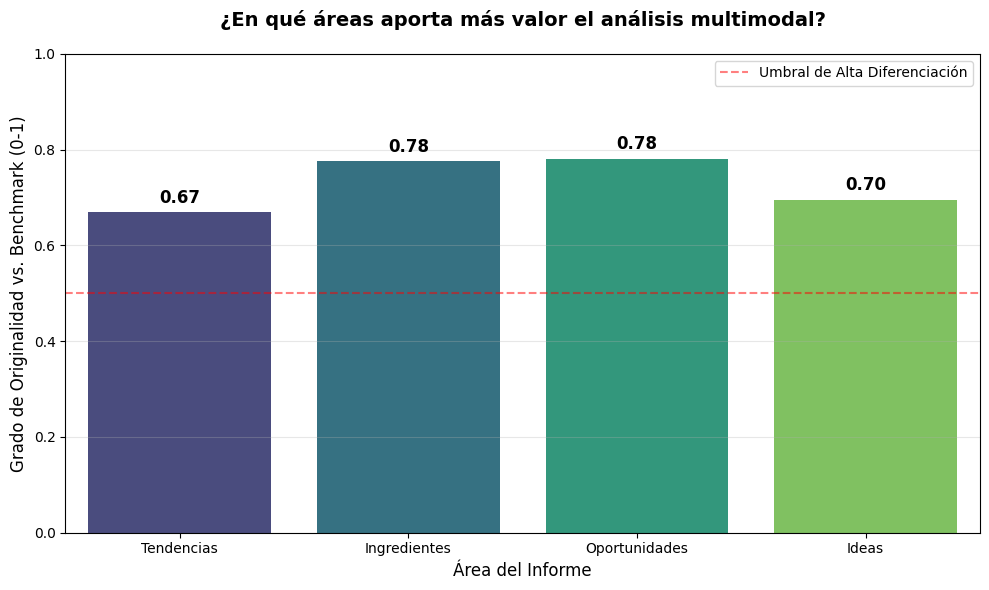

In [ ]:
# ==============================================================================
# VISUALIZACIÓN
# ==============================================================================
plt.figure(figsize=(10, 6))

# Usamos la métrica de ORIGINALIDAD (1 - Similitud) porque es positiva y vende mejor
# Cuanto más alta la barra, más "único" es tu informe respecto a Internet.

sns.barplot(
    data=df_similitud_secciones,
    x='Sección',
    y='Originalidad',
    palette='viridis'
)

plt.title("¿En qué áreas aporta más valor el análisis multimodal?", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Grado de Originalidad vs. Benchmark (0-1)", fontsize=12)
plt.xlabel("Área del Informe", fontsize=12)
plt.ylim(0, 1) # Escala de 0 a 100%

# Línea de referencia (0.5 es un buen punto de corte)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Umbral de Alta Diferenciación')
plt.legend()

# Etiquetas de valor encima de las barras
for i, v in enumerate(df_similitud_secciones['Originalidad']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

Los resultados muestran que las secciones Ingredientes y Oportunidades son las más originales respecto a los benchmarks, con valores cercanos a 0.78, indicando que aportan contenido diferencial y exclusivo.

La sección Ideas también mantiene un nivel alto de originalidad (0.70), mientras que Tendencias es algo menos diferenciada (0.67), lo que sugiere que los patrones de mercado y hábitos de consumo identificados están más alineados con el conocimiento general disponible.

En conjunto, el informe genera un análisis muy diferenciado en aspectos clave como ingredientes, oportunidades e ideas para innovación en snacks saludables, aportando valor estratégico a la empresa.

## Visualizaciones

En esta sección se presentan gráficos que permiten interpretar de manera rápida y visual los datos extraídos y enriquecidos con el modelo LLM Gemini.

In [2]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def limpiar_lista(valor):
    """Convierte strings o listas en lista limpia de strings."""
    if isinstance(valor, str):
        return [x.strip().lower() for x in valor.split(",") if x.strip()]
    elif isinstance(valor, list):
        return [str(x).strip().lower() for x in valor]
    return []

def mapear_categorias(lista_productos, mapa):
    """Mapea productos a categorías, filtrando irrelevantes y eliminando duplicados."""
    cats = [mapa.get(p) for p in lista_productos if mapa.get(p) not in ["No relevante para snacks", "Desconocido"]]
    return list(set(cats))

# ============================================================
# PREPARACIÓN DE COLUMNAS DERIVADAS
# ============================================================
df_viz = df.copy()

# Diccionario rápido de producto -> categoría
mapa_categorias = dict(zip(
    df_tipos_productos["Producto"].str.lower().str.strip(), 
    df_tipos_productos["Categoria"]
))

# Columnas derivadas
df_viz['Lista_Categorias'] = df_viz['Productos'].apply(lambda x: mapear_categorias(limpiar_lista(x), mapa_categorias))
df_viz['Lista_Atributos'] = df_viz['Atributos'].apply(limpiar_lista)
df_viz['Categoria_Principal'] = df_viz['Productos'].apply(
    lambda x: mapear_categorias(limpiar_lista(x), mapa_categorias)[:1][0] 
    if mapear_categorias(limpiar_lista(x), mapa_categorias) else None
)
df_viz['Sentimiento'] = df_viz['Sentimiento'].str.lower().str.strip()
df_sent = df_viz[df_viz['Sentimiento'].isin(['positivo', 'negativo', 'neutro'])].dropna(subset=['Categoria_Principal'])

print("\n✅ Columnas derivadas generadas. Datos listos para visualizaciones.")


✅ Columnas derivadas generadas. Datos listos para visualizaciones.


### Mapa de Calor de Atributos Valorados según Tipología de Producto

Creamos un mapa de calor para analizar qué aspectos valoran más los consumidores según el tipo de snack (ingredientes, sabor, conveniencia, etc.). Permite identificar drivers de consumo y prioridades del mercado.

In [4]:
df

,content_clean,source,type,Productos,Atributos,Sentimiento
0,titulo: recetas saludables contra el frío inve...,directoalpaladar,web,NaN,NaN,positivo
1,titulo: ejercicio físico en verano url: practi...,nutt,web,"agua, bebidas isotónicas, ropa ligera, ropa tr...","conveniencia, ingredientes, precio",positivo
2,titulo: el agua en las comidas no engorda url:...,nutt,web,NaN,NaN,positivo
3,"titulo: productos bio, veganos, sin gluten, si...",solnatural,web,"productos bio, productos veganos, productos si...",ingredientes,positivo
4,titulo: calabacín rebozado y crujiente en frei...,vitonica,web,"calabacín rebozado, patatas fritas de bolsa","ingredientes, conveniencia, textura, sabor",positivo
5,titulo: el mayor experto en longevidad del mun...,vitonica,web,"refrescos azucarados, snacks salados comercial...","ingredientes, conveniencia, sabor",negativo
6,titulo: el picoteo puede arruinar los benefici...,vitonica,web,"semillas, frutos secos, frutas frescas",ingredientes,negativo
7,titulo: los tres mejores snacks ricos en prote...,vitonica,web,"endivias rellenas de salmón, queso y aguacate,...","ingredientes, conveniencia, sabor",positivo
8,"titulo: marcos vázquez, creador de fitness rev...",vitonica,web,"snacks de ejercicio, micro entrenamientos, sen...","conveniencia, ingredientes",positivo
9,titulo: nueces crujientes a las finas hierbas:...,vitonica,web,"nueces, almendras, avellanas, cacahuetes, rawm...","textura, sabor, ingredientes, precio, convenie...",positivo


🖼️ Heatmap guardado en: H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\outputs\heatmap_drivers_consumo.png


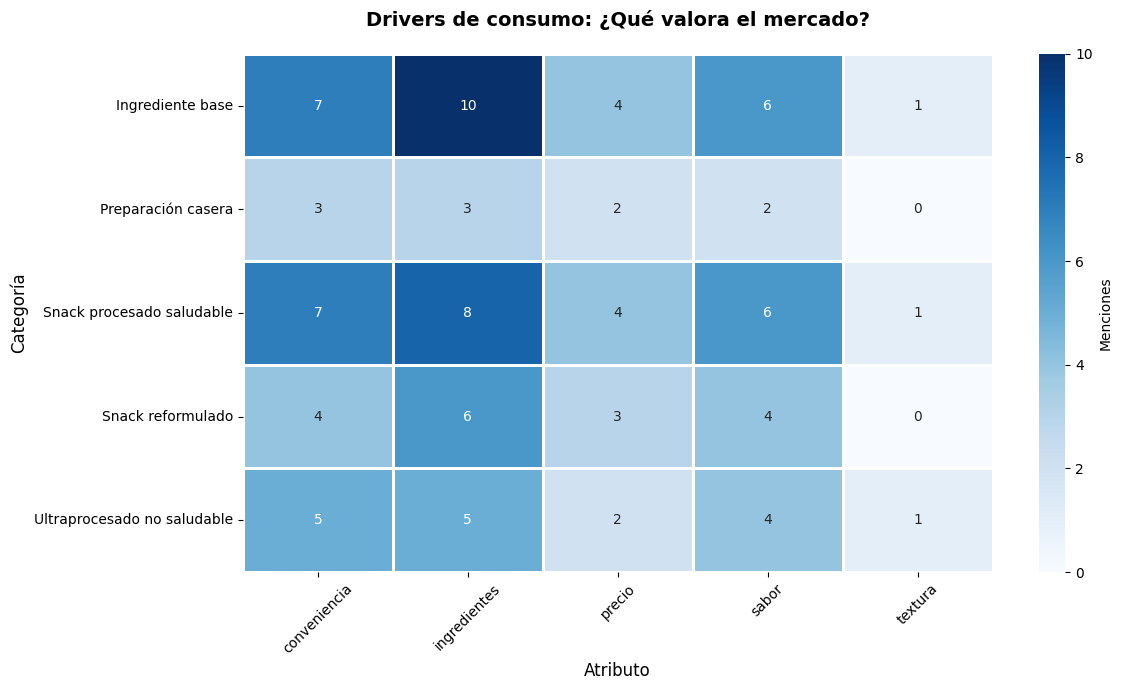

In [ ]:
# ============================================================
# HEATMAP DE CATEGORÍA VS ATRIBUTO
# ============================================================
# Carpeta de salida
OUTPUT_PATH = Path(r"H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\outputs")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
df_exploded = df_viz.explode('Lista_Categorias').explode('Lista_Atributos').dropna()
if not df_exploded.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    matriz = pd.crosstab(df_exploded['Lista_Categorias'], df_exploded['Lista_Atributos'])
    sns.heatmap(matriz, annot=True, fmt='d', cmap="Blues", linewidths=1, cbar_kws={'label': 'Menciones'}, ax=ax)
    ax.set_title("Drivers de consumo: ¿Qué valora el mercado?", fontsize=14, pad=20, fontweight='bold')
    ax.set_xlabel("Atributo", fontsize=12)
    ax.set_ylabel("Categoría", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Guardar imagen en la ruta absoluta
    ruta_heatmap = OUTPUT_PATH / "heatmap_drivers_consumo.png"
    fig.savefig(ruta_heatmap, dpi=300, bbox_inches='tight')
    print(f"🖼️ Heatmap guardado en: {ruta_heatmap}")
    
    plt.show()
else:
    print("⚠️ No hay datos suficientes para graficar heatmap.")

El mapa de calor revela que los Ingredientes son el factor más determinante para los consumidores, alcanzando su máximo interés (10 menciones) en la categoría de "Ingrediente base", y mostrando también una fuerte relevancia en los "Snacks procesados saludables", lo cual resulta coherente con las expectativas de calidad del mercado.

A continuación, Conveniencia y Sabor se consolidan como los principales motores de compra, destacando claramente sobre atributos como Precio o Textura, que presentan una menor presencia en las menciones.

En conjunto, estos resultados indican que el mercado prioriza la calidad de la composición y la facilidad de consumo por encima del coste. Esto sugiere que la innovación debería centrarse en etiquetas limpias y buen sabor, en lugar de competir principalmente en precio.

### Distribución de Sentimiento Ponderada por Volumen de Menciones

Graficamos el volumen de menciones positivas, neutras y negativas para cada tipo de snack. Las barras apiladas muestran tanto el peso relativo de cada sentimiento como la proporción dentro de la categoría, ofreciendo una visión clara de la percepción del consumidor.

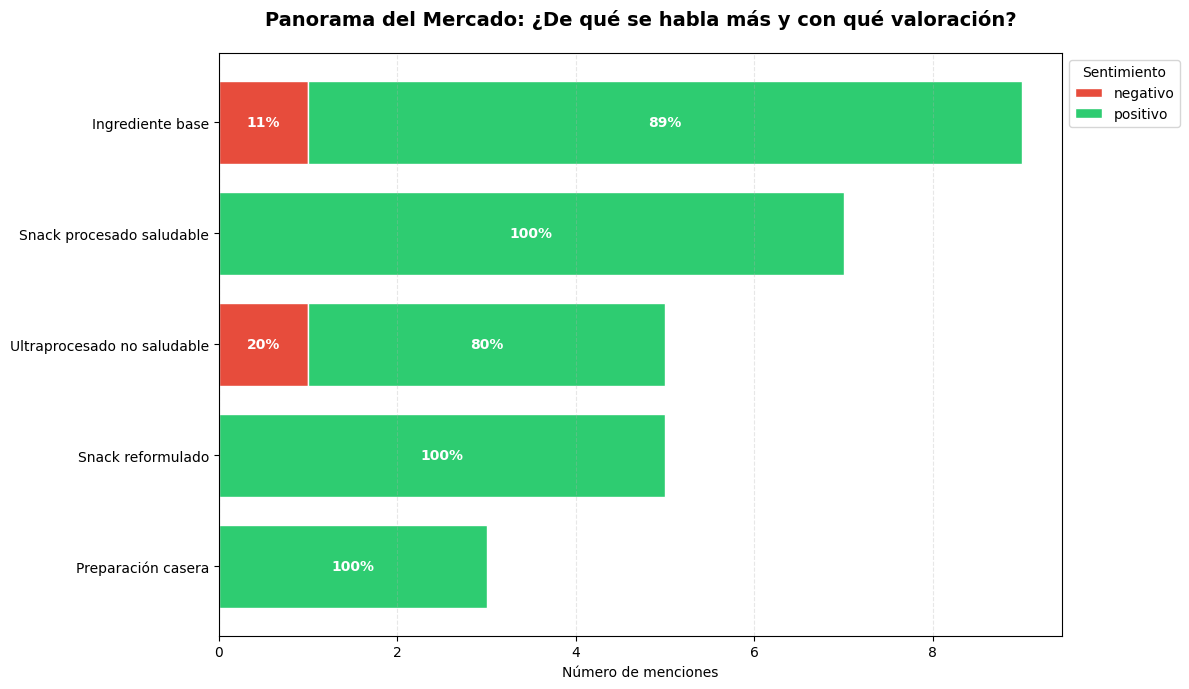

🖼️ Gráfico guardado en: H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\outputs\distribucion_categoria_sentimiento_menciones.png


In [ ]:
# ==============================
# BARRAS: CATEGORÍA vs SENTIMIENTO (nivel mención)
# ==============================
df_menciones = df_sent.explode('Lista_Categorias').dropna(subset=['Lista_Categorias'])

# Valores absolutos
tabla_absoluta = pd.crosstab(df_menciones['Lista_Categorias'], df_menciones['Sentimiento'])

# Orden por total
tabla_absoluta['Total'] = tabla_absoluta.sum(axis=1)
tabla_absoluta = tabla_absoluta.sort_values('Total', ascending=True)
tabla_absoluta.drop(columns='Total', inplace=True)

# Porcentajes
tabla_porcentajes = pd.crosstab(df_menciones['Lista_Categorias'], df_menciones['Sentimiento'], normalize='index')*100
tabla_porcentajes = tabla_porcentajes.reindex(tabla_absoluta.index)

# Colores
colores = {'negativo':'#e74c3c', 'neutro':'#95a5a6', 'positivo':'#2ecc71'}
colores_plot = [colores[c] for c in tabla_absoluta.columns]

# Plot
ax = tabla_absoluta.plot(kind='barh', stacked=True, figsize=(12,7), color=colores_plot, width=0.75, edgecolor='white')
ax.set_title("Panorama del Mercado: ¿De qué se habla más y con qué valoración?", fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("Número de menciones")
ax.set_ylabel("")
ax.legend(title="Sentimiento", bbox_to_anchor=(1,1), loc='upper left')
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Etiquetas porcentuales internas
for i, container in enumerate(ax.containers):
    labels=[]
    for j, val in enumerate(container.datavalues):
        if val>0:
            pct = tabla_porcentajes.iloc[j,i]
            labels.append(f"{pct:.0f}%" if pct>=5 else "")
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
ruta_barras = OUTPUT_PATH / "distribucion_categoria_sentimiento_menciones.png"
plt.savefig(ruta_barras, dpi=300, bbox_inches='tight')
plt.show()
print(f"🖼️ Gráfico guardado en: {ruta_barras}")


El gráfico de barras apiladas evidencia que el ‘Ingrediente base’ domina la conversación del mercado, con el mayor volumen de menciones y un alto porcentaje de aceptación positiva (89%), reflejando el interés principal de los consumidores por la calidad de la materia prima.

Por otro lado, la excelencia en valoración se encuentra en los productos transformados: tanto los “Snacks reformulados” como los “Snacks procesados saludables” muestran un 100% de sentimiento positivo, sin menciones negativas, lo que indica una percepción muy favorable de estas opciones cuando cumplen criterios de salud o reformulación.

En contraste, y como era de esperar, el ultraprocesado no saludable presenta el mayor porcentaje de sentimiento negativo (20%) entre todos los tipos de productos, reflejando la percepción crítica del consumidor frente a opciones menos saludables.

En conjunto, aunque la conversación se concentra en los ingredientes, el consumidor reconoce y premia las propuestas de snacks procesados de perfil saludable, sugiriendo que existe un espacio seguro y receptivo para la innovación, donde la combinación de buena calidad y perfil saludable genera aceptación plena.

### Exportar CSV 

Exportamos en CSV las tablas para generar las gráficas en Streamlit.

In [ ]:
# ============================================
# Carpeta de salida
# ============================================
OUTPUT_PATH = Path(r"H:\Cristina\Mis documentos\Github\TFM-2-A.Multimodal_snacks_saludables\outputs")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# ============================================
# CSV PARA HEATMAP: categoría x atributo
# ============================================
df_heatmap = df_viz.explode('Lista_Categorias').explode('Lista_Atributos').dropna(subset=['Lista_Categorias','Lista_Atributos'])
csv_heatmap = OUTPUT_PATH / "powerbi_heatmap.csv"
df_heatmap[['Lista_Categorias','Lista_Atributos','Sentimiento','source','type']].to_csv(csv_heatmap, index=False, encoding='utf-8')
print(f"✅ CSV de heatmap exportado: {csv_heatmap}")

# ============================================
# CSV PARA BARRAS: categoría vs sentimiento
# ============================================
df_menciones = df_sent.explode('Lista_Categorias').dropna(subset=['Lista_Categorias'])
csv_barras = OUTPUT_PATH / "powerbi_barras.csv"
df_menciones[['Lista_Categorias','Sentimiento','source','type']].to_csv(csv_barras, index=False, encoding='utf-8')
print(f"✅ CSV de barras exportado: {csv_barras}")

